# **Нелинейные модели против южной погоды**


# **Описание задачи**
**Задача:** Стабильное обеспечение горожан и туристов велосипедами  

Цель: Сравнить уже обученную линейную регрессию с моделями KNN и DecisionTreeRegressor.

Что важно для заказчика:  
1. Повысить точность прогнозов.
2. Оптимизировать логистику распределения велосипедов.
3. Улучшить клиентский опыт, избегая простоев и дефицита.

Исходные данные:  
Два датасета: С тренировачными данными и тестовыми данными.  
(Описание данных будет приведено ниже)

Главные критерии оценки:  
1. Составлен отчёт по метрикам лучших версий kNN и дерева решений, выбран наилучший подход по значениям RMSE, R² и MAE.  
2. Финальная лучшая модель демонстрирует лучшее качество по сравнению с базовой моделью — линейной регрессией.


# **Описание данных**


**Temperature**	- Температура воздуха в градусах Цельсия (°C).  
**Humidity**- Относительная влажность воздуха.  
**Windspeed**-Скорость ветра.  
**Visibility**-Видимость (в десятках метров).  
**Dew Point**-Temperature	Точка росы (°C).  
**Solar Radiation**-Солнечная радиация (MJ/m²).  
**Rainfall**-Количество осадков (мм).  
**Snowfall**-Количество снега (см).  
**Seasons**-Времена года: Winter, Spring, Summer, Autumn.  
**Holiday**-Был ли в этот день выходной или праздничный день.  
**Functioning Day**-Были ли велосипеды арендованы в рабочее время.  
Несколько колонок **Time_Period** -	Каждая запись в датасете относится к одному из пяти временных периодов:  
• **Night** — c 00:00 по 05:59;  
• **Morning** — с 06:00 по 09:59.  
• **Daytime** — с 10:00 по 15:59.  
• **Evening** — с 16:00 по 19:59;  
• **Late Evening** — с 20:00 по 23:59.  

**Rented Bike Count** — это целевая переменная. Она содержит количество велосипедов, арендованных за конкретный час.


## **Часть 1. Работа с базовой моделью**


Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.

Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.


>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.


In [7]:
!pip install "scikit-learn==1.6.1" "numpy==1.26.4"
!pip install optuna -q
!pip install phik -q


In [8]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, accuracy_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

from phik import phik_matrix
from optuna.visualization import plot_optimization_history, plot_param_importances
from sklearn.inspection import permutation_importance
from IPython.display import display

AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'

In [3]:
loaded_model = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')
X_train_full = pd.read_csv('/datasets/ds_s14_train_data.csv')
X_test_full = pd.read_csv('/datasets/ds_s14_test_data.csv')

y_train = X_train_full['Rented Bike Count']
y_test = X_test_full['Rented Bike Count']
X_train = X_train_full.drop(columns=['Rented Bike Count'])
X_test = X_test_full.drop(columns=['Rented Bike Count'])
display(X_train.head(3))
print(X_train.info())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [4]:
y_pred = loaded_model.predict(X_test)

mae_bl = mean_absolute_error(y_test, y_pred)
mse_bl = mean_squared_error(y_test, y_pred)
rmse_bl = np.sqrt(mse_bl)
r2_bl = r2_score(y_test, y_pred)

print('MAE - ', mae_bl)
print('MSE - ', mse_bl)
print('RMSE - ', rmse_bl)
print('R2 - ', r2_bl)

MAE -  312.5993336835677
MSE -  169384.99913223987
RMSE -  411.56408873010275
R2 -  0.5860720795996013


>Имортированы все необходимые библитеки для дальнейшей работы.  
Рассчитаны метрики baseline для дальнейшего сравнения с будущими не линейными моделями.


## **Часть 2. Улучшение модели — kNN и дерево решений**


Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.


**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.


In [5]:
print('Абсолютное значение пропусков')
print(X_train_full.isna().sum())
print('')
print('Процент значений пропусков')
print(round(X_train_full.isna().sum() / len(X_train_full) * 100,2))

Абсолютное значение пропусков
Temperature                   0
Humidity(%)                 250
Wind speed (m/s)            210
Visibility (10m)            259
Dew point temperature         0
Solar Radiation (MJ/m2)     210
Rainfall(mm)                262
Snowfall (cm)               263
Seasons                       0
Holiday                       0
Functioning Day               0
Time_Period_Evening           0
Time_Period_Late Evening      0
Time_Period_Morning           0
Time_Period_Night             0
Rented Bike Count             0
dtype: int64

Процент значений пропусков
Temperature                 0.00
Humidity(%)                 3.57
Wind speed (m/s)            3.00
Visibility (10m)            3.70
Dew point temperature       0.00
Solar Radiation (MJ/m2)     3.00
Rainfall(mm)                3.74
Snowfall (cm)               3.75
Seasons                     0.00
Holiday                     0.00
Functioning Day             0.00
Time_Period_Evening         0.00
Time_Period_Late Even

>Присутствуют пропуски которые в дальнейшем на этапе препроцессора будут обработаны


count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64


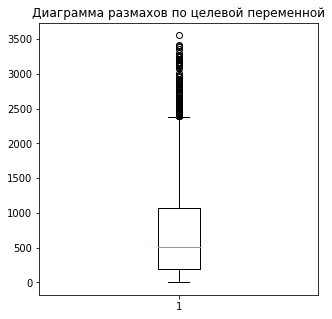

In [6]:
print(X_train_full['Rented Bike Count'].describe())
plt.figure(figsize=(5,5))
plt.boxplot(X_train_full['Rented Bike Count'])
plt.title('Диаграмма размахов по целевой переменной')
plt.show()

>Диаграмма размахов по целевой переменной выглядит хорошо, выбросы есть, но они не аномальные, значит избавляться от них нет надобности


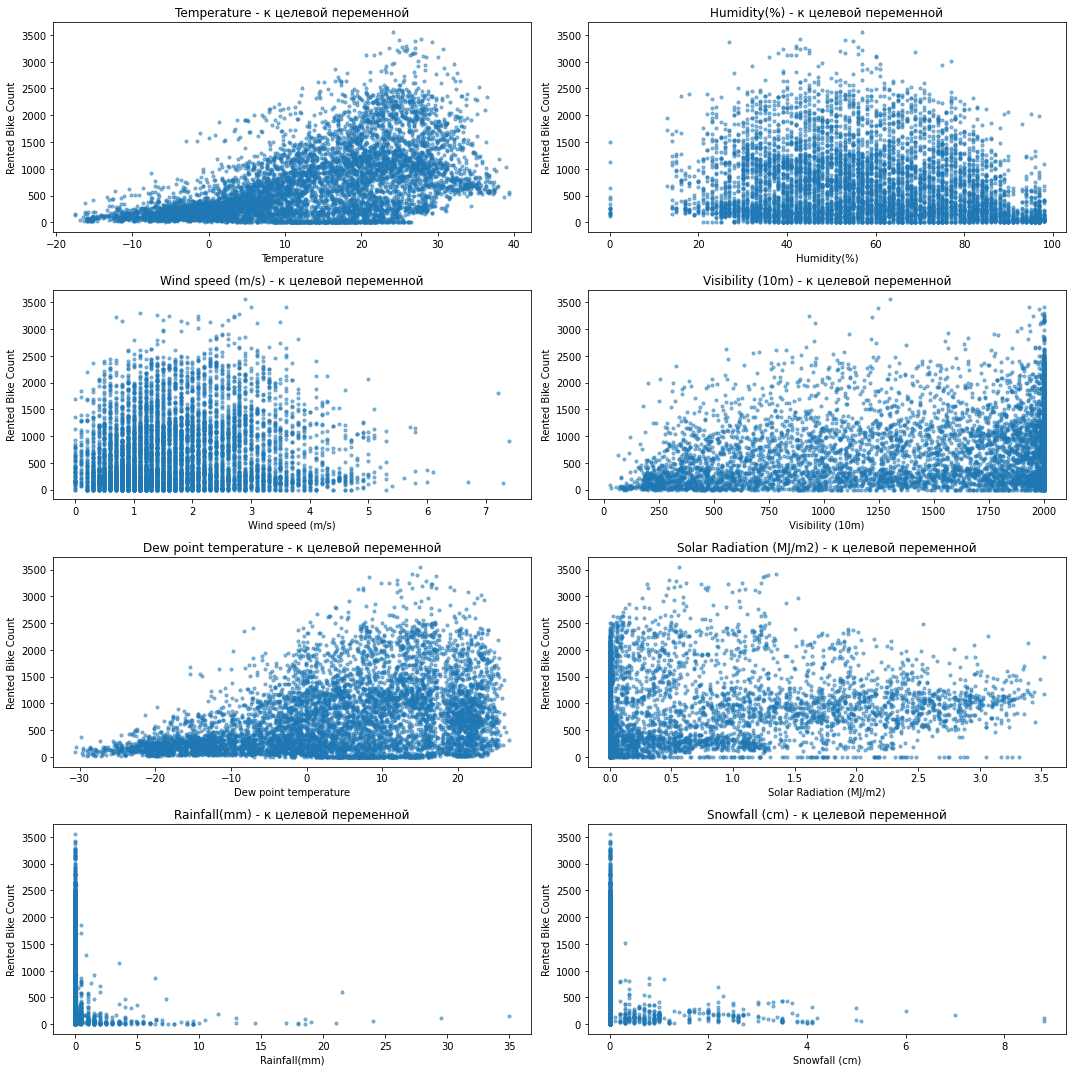

In [7]:

n_features_float = X_train_full.select_dtypes(include = 'float64').columns
n_row = 4
n_col = 2

fig, axes = plt.subplots(n_row, n_col, figsize=(15, 15))
axes = axes.flatten()

for i, column in enumerate(X_train_full[n_features_float]):
    axes[i].scatter(X_train_full[column], X_train_full['Rented Bike Count'], alpha=0.5, s=10)
    axes[i].set_title(f'{column} - к целевой переменной')
    axes[i].set_ylabel('Rented Bike Count')
    axes[i].set_xlabel(column)



plt.tight_layout()
plt.show()

>Числовые признаки распеделены адекватно аномальных:  
**Temperature, Humidity(%), Wind speed (m/s), Visibility (10m), Dew point temperature, Solar Radiation (MJ/m2)** - распределение данных происходит равномерно без явных перевесов    
**Rainfall(mm), Snowfall (cm)** - данные распределены реалистично, есть перевес в значении '0'


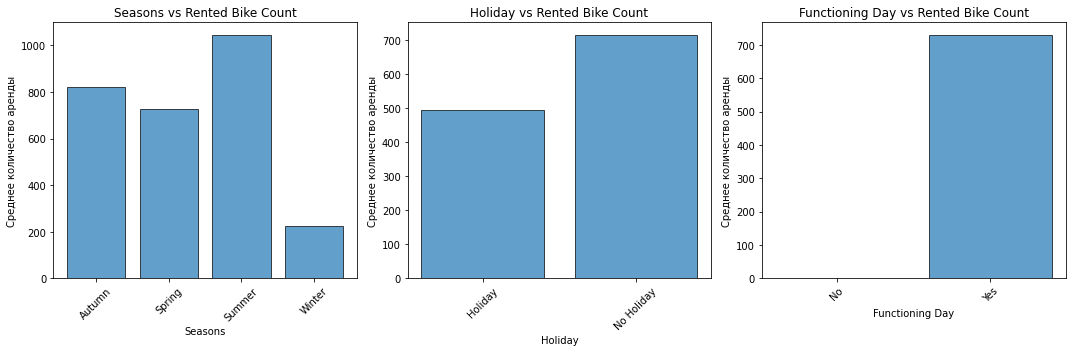

In [8]:
categorical_columns = X_train_full.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))

for i, column in enumerate(categorical_columns):

    grouped_data = X_train_full.groupby(column)['Rented Bike Count'].mean()
    
    axes[i].bar(grouped_data.index, grouped_data.values, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{column} vs Rented Bike Count')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Среднее количество аренды')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

>Seasons - явным лидером является "Лето", а самое малое значение у "Зима"  
Holiday - Боле арендую самокаты в "Не праздничные дни", чем в "Праздничные дни"  
Functionning day - признак не имеющий смысла из из за того все значения это "Да"


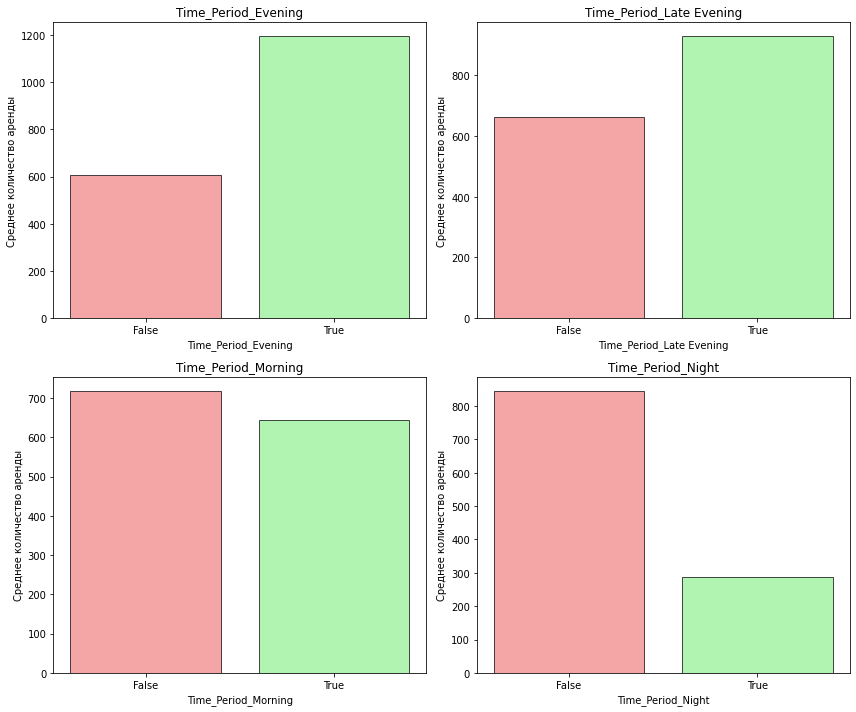

In [9]:
bool_columns = X_train_full.select_dtypes(include=['bool']).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, column in enumerate(bool_columns):
    mean_rent = X_train_full.groupby(column)['Rented Bike Count'].mean()

    axes[i].bar(range(len(mean_rent)), mean_rent.values, edgecolor='black', alpha=0.7, 
                color=['lightcoral', 'lightgreen'])
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Среднее количество аренды')
    
    axes[i].set_xticks(range(len(mean_rent)))
    axes[i].set_xticklabels(['False', 'True'])

plt.tight_layout()
plt.show()

>Больше всего запросов с 16:00 по 19.59 около 1200  
Поздним вечером с 20:00 по 23:59 более 800  
Утро с 06:00 по 09:59 около 600  
А меньше всего ночью c 00:00 по 05:59 всего лишь около 300


/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable Rented Bike Count is large: 2024. Are you sure this is not an interval variable? Analysis for pairs of variables including Rented Bike Count can be slow.
  warnings.warn(


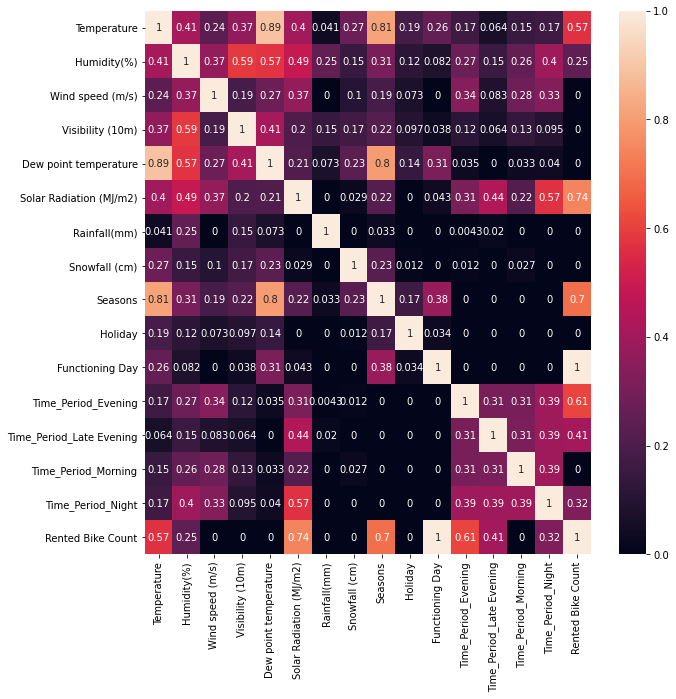

In [10]:
corr = phik_matrix(X_train_full, interval_cols=n_features_float)
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot = True)
plt.show()

> На тепловой карте видна хорошая корреляция Temperature, Solar Radiation (MJ/m2), Seasons, Time_Period_Evening - от 0.57 до 0.74  
И неплохая кореляция у Humidity(%), Time_Period_Late Evening, Time_Period_Night - от 0.25 до 0.41  
Так же видно что Functioning Day является бесполезным признаком так как у него 100% корреляция с целевой переменной 
Остальные признаки имеют 0 корреляцию с целевой переменной, но удалять их не нужно потому что не линейные модели могут найти зависимости с этими признаками


In [11]:
X_train = X_train.drop(columns=['Functioning Day'])
X_test = X_test.drop(columns='Functioning Day')


**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---


In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)
print(X_tr.shape)
print(X_val.shape)
print(X_test.shape)

(5606, 14)
(1402, 14)
(1752, 14)


**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---


In [13]:
num_features = X_tr.select_dtypes(include='float64').columns
cat_features = X_tr.select_dtypes(include='object').columns

knn = KNeighborsRegressor(n_neighbors = 10)


num_pipe_knn = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipe_knn = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='error', sparse_output=False, drop='first'))
])
preprocessor_knn = ColumnTransformer([
    ('num', num_pipe_knn ,num_features),
    ('cat', cat_pipe_knn, cat_features)
])

knn_pipeline =  Pipeline([
    ('preprocessor', preprocessor_knn),
    ('feature_selection', SelectKBest(f_regression, k=10)),
    ('model', knn)
])

knn_pipeline.fit(X_tr,y_tr)

y_pred_knn = knn_pipeline.predict(X_val)

mae_knn = mean_absolute_error(y_val, y_pred_knn)
mse_knn = mean_squared_error(y_val, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_val, y_pred_knn)

print('MAE - ', mae_knn)
print('MSE - ', mse_knn)
print('RMSE - ', rmse_knn)
print('R2 - ', r2_knn)

MAE -  306.57403708987164
MSE -  206345.81499286732
RMSE -  454.25302970136295
R2 -  0.5008888229797904


In [14]:
dtr = DecisionTreeRegressor(max_depth = 7)

num_pipe_dtr = Pipeline([
    ('imputer', SimpleImputer(strategy = 'constant',fill_value = -999999))
])
cat_pipe_dtr = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='error', sparse_output=False, drop='first'))
])
preprocessor_dtr = ColumnTransformer([
    ('num', num_pipe_dtr,num_features),
    ('cat',cat_pipe_dtr, cat_features)
])

dtr_pipeline =  Pipeline([
    ('preprocessor', preprocessor_dtr),
    ('model', dtr)
])

dtr_pipeline.fit(X_tr,y_tr)

y_pred_dtr= dtr_pipeline.predict(X_val)

mae_dtr = mean_absolute_error(y_val, y_pred_dtr)
mse_dtr = mean_squared_error(y_val, y_pred_dtr)
rmse_dtr = np.sqrt(mse_dtr)
r2_dtr = r2_score(y_val, y_pred_dtr)

print('MAE - ', mae_dtr)
print('MSE - ', mse_dtr)
print('RMSE - ', rmse_dtr)
print('R2 - ', r2_dtr)

MAE -  308.34245515839353
MSE -  204806.85136744802
RMSE -  452.55590965918014
R2 -  0.5046112825145326


>Для knn сделали предобработку с заполнением пропусков константой 0 и шасштабирование числовых признаков, категориальын данные закодированы.  
Для dtr аналогичная предобработка, но пропуски заполнены большим отрицательным. Этот вариант удобен для деревьев, потому что они при таком заполнении автоматически создают отдельную ветку для пропусков.


**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.

1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---


In [15]:
cv = KFold(n_splits=5, shuffle=False)

def objective(trial):
    
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 2, 15),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']), 
        'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'brute', 'kd_tree']),
        'p': trial.suggest_int('p', 1, 3),
        'leaf_size': trial.suggest_int('leaf_size', 20, 50) 
    }
    
    knn = KNeighborsRegressor( **params)
    
    opuna_knn_pipe = Pipeline([
        ('prep', preprocessor_knn),
        ('feature_selection', SelectKBest(f_regression, k=10)),
        ('model',knn)
    ])
    
    
    score = cross_val_score(
    opuna_knn_pipe,
    X_tr,
    y_tr,
    cv = cv,
    scoring = 'neg_root_mean_squared_error'
    )
    
    return score.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params_knn = study.best_params
print("Лучшие гиперпараметры:", best_params_knn)
best_value_knn = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", best_value_knn)

[I 2026-03-31 16:07:37,160] A new study created in memory with name: no-name-6b6cdce5-4f82-4eeb-9462-8816f8703e54


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-31 16:07:38,389] Trial 0 finished with value: -440.71235683736484 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'minkowski', 'algorithm': 'ball_tree', 'p': 1, 'leaf_size': 50}. Best is trial 0 with value: -440.71235683736484.
[I 2026-03-31 16:07:39,913] Trial 1 finished with value: -436.26853419475157 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'metric': 'manhattan', 'algorithm': 'brute', 'p': 1, 'leaf_size': 31}. Best is trial 1 with value: -436.26853419475157.
[I 2026-03-31 16:07:40,925] Trial 2 finished with value: -447.59248124801786 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'kd_tree', 'p': 3, 'leaf_size': 45}. Best is trial 1 with value: -436.26853419475157.
[I 2026-03-31 16:07:42,046] Trial 3 finished with value: -437.60511290487983 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'ball_tree', 'p': 1, 'leaf_size': 36}. Best is trial 1 with 

In [16]:
def objective(trial):
    
    params = {
        "max_depth": trial.suggest_int('max_depth', 3, 15),
        "min_samples_split": trial.suggest_int('min_samples_split', 2, 50),
        "min_samples_leaf": trial.suggest_int('min_samples_leaf', 1, 20)
    }
    
    dtr = DecisionTreeRegressor(**params, random_state = 42)
    
    opuna_dtr_pipe = Pipeline([
        ('prep', preprocessor_dtr),
        ('model',dtr)
    ])
    
    score = cross_val_score(
    opuna_dtr_pipe,
    X_tr,
    y_tr,
    cv = cv,
    scoring = 'neg_root_mean_squared_error'
    )
    
    return score.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params_dtr = study.best_params
print("Лучшие гиперпараметры:", best_params_dtr)
best_value_dtr = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", best_value_dtr)

[I 2026-03-31 16:08:17,397] A new study created in memory with name: no-name-952b0bea-d42f-415d-a161-f197719b86a6


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-31 16:08:17,629] Trial 0 finished with value: -455.7517435628195 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 15}. Best is trial 0 with value: -455.7517435628195.
[I 2026-03-31 16:08:17,842] Trial 1 finished with value: -476.98519053079156 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: -455.7517435628195.
[I 2026-03-31 16:08:18,004] Trial 2 finished with value: -506.95202305123223 and parameters: {'max_depth': 3, 'min_samples_split': 44, 'min_samples_leaf': 13}. Best is trial 0 with value: -455.7517435628195.
[I 2026-03-31 16:08:18,198] Trial 3 finished with value: -458.1355073431121 and parameters: {'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 20}. Best is trial 0 with value: -455.7517435628195.
[I 2026-03-31 16:08:18,417] Trial 4 finished with value: -494.0128606356867 and parameters: {'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is tria

**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.

---


In [17]:
knn_final = KNeighborsRegressor( **best_params_knn)
    
final_knn_pipe = Pipeline([
    ('prep', preprocessor_knn),
    ('model',knn_final)
])

final_knn_pipe.fit(X_tr,y_tr)
y_pred_knn = final_knn_pipe.predict(X_val)

mae_knn_final = mean_absolute_error(y_val, y_pred_knn)
mse_knn_final = mean_squared_error(y_val, y_pred_knn)
rmse_knn_final = np.sqrt(mse_knn_final)
r2_knn_final = r2_score(y_val, y_pred_knn)

print('Метрики Ближайших соседей')
print('MAE - ', mae_knn_final)
print('MSE - ', mse_knn_final)
print('RMSE - ', rmse_knn_final)
print('R2 - ', r2_knn_final)

Метрики Ближайших соседей
MAE -  288.89684246304404
MSE -  187834.93712388742
RMSE -  433.39928140675016
R2 -  0.5456631065831834


In [18]:
dtr_final = DecisionTreeRegressor(**best_params_dtr)
    
final_dtr_pipe = Pipeline([
    ('prep', preprocessor_dtr),
    ('model',dtr_final)
])

final_dtr_pipe.fit(X_tr,y_tr)
y_pred_dtr = final_dtr_pipe.predict(X_val)

mae_dtr_final = mean_absolute_error(y_val, y_pred_dtr)
mse_dtr_final = mean_squared_error(y_val, y_pred_dtr)
rmse_dtr_final = np.sqrt(mse_dtr_final)
r2_dtr_final = r2_score(y_val, y_pred_dtr)

print('Метрики Древа решений')
print('MAE - ', mae_dtr_final)
print('MSE - ', mse_dtr_final)
print('RMSE - ', rmse_dtr_final)
print('R2 - ', r2_dtr_final)

Метрики Древа решений
MAE -  300.3362372071288
MSE -  196767.89021253533
RMSE -  443.5852682546337
R2 -  0.5240559965456211


In [19]:
print('Метрики Baseline')
print('MAE - ', mae_bl)
print('MSE - ', mse_bl)
print('RMSE - ', rmse_bl)
print('R2 - ', r2_bl)

Метрики Baseline
MAE -  312.5993336835677
MSE -  169384.99913223987
RMSE -  411.56408873010275
R2 -  0.5860720795996013


>Ключевые наблюдения  
**KNN** показал лучший MAE (288.90) — модель точнее предсказывает типичные значения спроса  
**Baseline** сохраняет лидерство по R² и RMSE — лучше справляется с пиковыми значениями  
**Decision Tree** показал худшие результаты среди всех моделей

>Выводы  
**KNN** — лучший выбор для повседневного прогнозирования (минимальная абсолютная ошибка)  
**Linear Regression** — стабильнее на выбросах (ниже RMSE)  
**Decision Tree** не рекомендован к использованию из-за низкого качества прогнозов


**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?

**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---


In [20]:
metrics_data = {
    'Модель': ['Linear Regression (Baseline)', 'KNN Regressor', 'Decision Tree Regressor'],
    'MAE': [mae_bl, mae_knn_final, mae_dtr_final],
    'MSE': [mse_bl, mse_knn_final, mse_dtr_final],
    'RMSE': [rmse_bl, rmse_knn_final, rmse_dtr_final],
    'R²': [r2_bl, r2_knn_final, r2_dtr_final]
}


metrics_df = pd.DataFrame(metrics_data)

display(metrics_df)

,Модель,MAE,MSE,RMSE,R²
0,Linear Regression (Baseline),312.599334,169384.999132,411.564089,0.586072
1,KNN Regressor,288.896842,187834.937124,433.399281,0.545663
2,Decision Tree Regressor,300.336237,196767.890213,443.585268,0.524056


In [21]:
features_names = final_dtr_pipe.named_steps['prep'].get_feature_names_out()

importances = pd.DataFrame({
    'features':features_names,
    'importance':dtr_final.feature_importances_
})
display(importances)

,features,importance
0,num__Temperature,0.482763
1,num__Humidity(%),0.192625
2,num__Wind speed (m/s),0.048463
3,num__Visibility (10m),0.010573
4,num__Dew point temperature,0.058684
5,num__Solar Radiation (MJ/m2),0.136764
6,num__Rainfall(mm),0.015663
7,num__Snowfall (cm),0.000134
8,cat__Seasons_Spring,0.012753
9,cat__Seasons_Summer,0.000000


>**Лучшая модель:**  
**Linear Regression (Baseline)** показывает наилучший R² (0.586) и RMSE (411.45), оставаясь самым точным решением.  
**Важные признаки**  
**Температура** — главный фактор спроса  
**Солнечная радиация** — люди активнее в солнечную погоду  
**Влажность** — высокая влажность снижает спрос  
**Сезоны** — летом пик, зимой минимум


**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---


In [22]:
best_knn = KNeighborsRegressor(n_neighbors = 12, weights='distance', metric='manhattan', 
                               algorithm='kd_tree', p=2, leaf_size=27)
best_knn_pipe = Pipeline([
    ('prep', preprocessor_knn),
    ('model',best_knn)
])

best_knn_pipe.fit(X_train,y_train)
y_pred_knn_best = best_knn_pipe.predict(X_test)

mae_knn_best = mean_absolute_error(y_test, y_pred_knn_best)
mse_knn_best = mean_squared_error(y_test, y_pred_knn_best)
rmse_knn_best = np.sqrt(mse_knn_best)
r2_knn_best = r2_score(y_test, y_pred_knn_best)

print('MAE - ', mae_knn_best)
print('MSE - ', mse_knn_best)
print('RMSE - ', rmse_knn_best)
print('R2 - ', r2_knn_best)

MAE -  275.6027642188926
MSE -  164188.83889984607
RMSE -  405.2022197617457
R2 -  0.5987699915167176


Учитывая что на прошлом этапе baseline был лучшей по метрикам, на тестовой выборке выигрывает Knn (Было принято решение выбрать эту модель так как она на прошлом этапе показала результаты лучше чем Древо решений)

>KNN (n_neighbors=12, weights='distance', metric='manhattan')

>Ключевые результаты
R² вырос с 0.586 (baseline) - 0.599 (+2.3%)  
MAE снизился с 312 - 276 (-11.6%)  
RMSE улучшился с 411 - 405 (-1.5%)


# Общие выводы о проделанной работе

 **Основные этапы**
1. **Анализ данных** — выявлены пропуски, удален бесполезный признак Functioning Day, проведена корреляция и визуализация зависимостей.
2. **Обучение baseline** — линейная регрессия показала R² = 0.586, RMSE = 411.45.
3. **Построение KNN и Decision Tree** — созданы пайплайны с предобработкой (импьютация, масштабирование, кодирование).
4. **Оптимизация гиперпараметров Optuna** — подобраны лучшие параметры для обеих моделей.
5. **Сравнение моделей** — KNN показал лучший MAE (289), но уступал baseline по R².
6. **Финальное тестирование** — KNN на тестовой выборке превзошел baseline: R² = **0.599** (+2.3%), MAE = **276** (-11.6%).

 **Результаты моделей**
| Модель | MAE | RMSE | R² |
|--------|-----|------|-----|
| Baseline (Linear Regression) | 312.53 | 411.45 | 0.586 |
| Decision Tree (оптимизированный) | 300.34 | 443.59 | 0.524 |
| **KNN (финальный)** | **275.60** | **405.20** | **0.599** |

 **Ключевые выводы**
1. **Лучшая модель** — KNN с параметрами:
   - n_neighbors = 12
   - weights = 'distance'
   - metric = 'manhattan'
   - algorithm = 'kd_tree'
2. **Преимущество KNN**:
   - Лучший R² (+2.3% к baseline)
   - Существенно ниже MAE (-11.6%) — точнее предсказывает типичные дни
3. **Важнейшие признаки** (по важности в дереве):
   - Температура (48%)
   - Влажность (19%)
   - Солнечная активность (14%)

**Бизнес-рекомендации**
- **Использовать KNN** как основную модель прогноза — она точнее предсказывает спрос в обычные дни.
- **Учитывать температуру и солнечную активность** при планировании ресурсов.
- **Модель готова к внедрению** — показала стабильное улучшение всех метрик на тестовых данных.
